In [2]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from paths import RAW_DIR, PROCESSED_DIR

In [3]:
orders = pd.read_csv(RAW_DIR / "orders.csv")
prior = pd.read_csv(RAW_DIR / "order_products__prior.csv")
train = pd.read_csv(RAW_DIR / "order_products__train.csv")

order_id             828824
product_id           828824
add_to_cart_order    828824
reordered            828824
dtype: int64


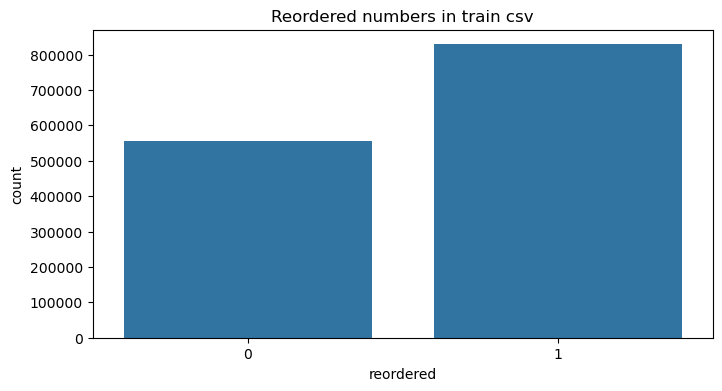

In [4]:
print(train[train['reordered'] == 1].count())

plt.figure(figsize=(8, 4)) # Optional: adjust the figure size
sns.countplot(x='reordered', data=train)
plt.title('Reordered numbers in train csv') # Add a title
plt.show()

In [5]:
orders.head()

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.0
2,473747,1,prior,3,3,12,21.0
3,2254736,1,prior,4,4,7,29.0
4,431534,1,prior,5,4,15,28.0


In [6]:
prior.head()

,order_id,product_id,add_to_cart_order,reordered
0,2,33120,1,1
1,2,28985,2,1
2,2,9327,3,0
3,2,45918,4,1
4,2,30035,5,0


In [7]:
train.head()

,order_id,product_id,add_to_cart_order,reordered
0,1,49302,1,1
1,1,11109,2,1
2,1,10246,3,0
3,1,49683,4,0
4,1,43633,5,1


# Downsample, keep only 2000 users

In [8]:
# Visualise user 2 data
orders[orders['user_id']==2]

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
11,2168274,2,prior,1,2,11,NaN
12,1501582,2,prior,2,5,10,10.0
13,1901567,2,prior,3,1,10,3.0
14,738281,2,prior,4,2,10,8.0
15,1673511,2,prior,5,3,11,8.0
16,1199898,2,prior,6,2,9,13.0
17,3194192,2,prior,7,2,12,14.0
18,788338,2,prior,8,1,15,27.0
19,1718559,2,prior,9,2,9,8.0
20,1447487,2,prior,10,1,11,6.0


### Choose 2000 random users and filter only sampled users

In [9]:
sample_users = orders['user_id'].drop_duplicates().sample(n=2000, random_state=42)
orders = orders[orders['user_id'].isin(sample_users)]

prior = prior[prior['order_id'].isin(orders['order_id'])]
train = train[train['order_id'].isin(orders['order_id'])]

### Check columns with same name 

In [10]:
prior.columns.intersection(orders.columns)

Index(['order_id'], dtype='object')

### Attach user_id and order_number to the historical prior dataset

In [11]:
prior_merged = prior.merge(orders[['order_id', 'user_id', 'order_number', 'days_since_prior_order']], on='order_id')

In [12]:
# check non null columns
prior_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303861 entries, 0 to 303860
Data columns (total 7 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                303861 non-null  int64  
 1   product_id              303861 non-null  int64  
 2   add_to_cart_order       303861 non-null  int64  
 3   reordered               303861 non-null  int64  
 4   user_id                 303861 non-null  int64  
 5   order_number            303861 non-null  int64  
 6   days_since_prior_order  283930 non-null  float64
dtypes: float64(1), int64(6)
memory usage: 16.2 MB


In [13]:
# Check data with days since prior order is null 
prior_merged[prior_merged['days_since_prior_order'].isna()]

,order_id,product_id,add_to_cart_order,reordered,user_id,order_number,days_since_prior_order
79,270,22275,1,0,201517,1,NaN
80,270,14999,2,0,201517,1,NaN
81,270,21641,3,0,201517,1,NaN
82,270,33189,4,0,201517,1,NaN
83,270,30776,5,0,201517,1,NaN
...,...,...,...,...,...,...,...
303844,3420874,35951,6,0,172119,1,NaN
303845,3420874,13854,7,0,172119,1,NaN
303846,3420874,22677,8,0,172119,1,NaN
303847,3420874,14462,9,0,172119,1,NaN


In [14]:
# Fill first orders having a NaN for days_since_prior_order with 0
prior_merged['days_since_prior_order'] = prior_merged['days_since_prior_order'].fillna(0)

In [15]:
# Check all the columns are non-null 
prior_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303861 entries, 0 to 303860
Data columns (total 7 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                303861 non-null  int64  
 1   product_id              303861 non-null  int64  
 2   add_to_cart_order       303861 non-null  int64  
 3   reordered               303861 non-null  int64  
 4   user_id                 303861 non-null  int64  
 5   order_number            303861 non-null  int64  
 6   days_since_prior_order  303861 non-null  float64
dtypes: float64(1), int64(6)
memory usage: 16.2 MB


In [16]:
prior_merged.head()

,order_id,product_id,add_to_cart_order,reordered,user_id,order_number,days_since_prior_order
0,28,35108,1,0,98256,29,6.0
1,28,40593,2,1,98256,29,6.0
2,28,17461,3,0,98256,29,6.0
3,28,22825,4,1,98256,29,6.0
4,28,25256,5,1,98256,29,6.0


## User Features

In [17]:
# user_total_orders: Total number of times a user bought an item 
# user_avg_days_between: Average of days between prior and next order (to know the frequency a user buys an item)
user_features = prior_merged.groupby('user_id').agg(
    user_total_orders=('order_number', 'max'),
    user_avg_days_between=('days_since_prior_order', 'mean')
).reset_index()

In [18]:
user_features

,user_id,user_total_orders,user_avg_days_between
0,102,6,19.542373
1,106,3,7.121951
2,130,3,21.891892
3,239,5,17.555556
4,273,19,14.861111
...,...,...,...
1995,205594,4,20.466667
1996,205693,3,16.363636
1997,205827,9,18.356643
1998,206054,31,12.198718


## Product Features

In [19]:
# prod_total_purchases: Total number of times a product is bought
# prod_reorder_ratio
product_features = prior_merged.groupby('product_id').agg(
    prod_total_purchases=('order_id', 'count'),
    prod_reorder_ratio=('reordered', 'mean')
).reset_index()

In [20]:
product_features

,product_id,prod_total_purchases,prod_reorder_ratio
0,1,12,0.416667
1,4,3,0.000000
2,9,2,0.000000
3,10,21,0.476190
4,11,2,0.500000
...,...,...,...
20426,49677,3,0.666667
20427,49678,3,0.000000
20428,49680,9,0.333333
20429,49683,1035,0.712077


## User-Product Interaction Features

In [21]:
# up_total_bought: Number of times a user bought a product
# To find the relationship between user and product to predict if a user will rebuy it 
user_product_features = prior_merged.groupby(['user_id', 'product_id']).agg(
    up_total_bought=('order_id', 'count')
).reset_index()

In [22]:
user_product_features

,user_id,product_id,up_total_bought
0,102,4920,3
1,102,8174,1
2,102,9839,3
3,102,12845,1
4,102,13629,1
...,...,...,...
126525,206126,48174,1
126526,206126,48364,1
126527,206126,48398,7
126528,206126,48437,1


# Final dataset

In [23]:
# Start with the user-product combinations as the base
final_df = user_product_features.copy()

# Attach the user and product features
final_df = final_df.merge(user_features, on='user_id')
final_df = final_df.merge(product_features, on='product_id')

In [24]:
final_df

,user_id,product_id,up_total_bought,user_total_orders,user_avg_days_between,prod_total_purchases,prod_reorder_ratio
0,102,4920,3,6,19.542373,816,0.670343
1,102,8174,1,6,19.542373,436,0.653670
2,102,9839,3,6,19.542373,430,0.746512
3,102,12845,1,6,19.542373,88,0.352273
4,102,13629,1,6,19.542373,208,0.783654
...,...,...,...,...,...,...,...
126525,206126,48174,1,29,12.971374,6,0.000000
126526,206126,48364,1,29,12.971374,157,0.439490
126527,206126,48398,7,29,12.971374,8,0.750000
126528,206126,48437,1,29,12.971374,43,0.186047


In [25]:
true_reorders = train[train['reordered'] == 1]

# Attach user_id to reorders
train_orders = orders[orders['eval_set'] == 'train'][['order_id', 'user_id']]
train_purchases = true_reorders.merge(train_orders, on='order_id')[['user_id', 'product_id']]
train_purchases = train_purchases[train_purchases['user_id'].isin(final_df['user_id'])]

# Create ML target label after feature engineering
train_purchases['reordered'] = 1

In [26]:
train_orders

,order_id,user_id
1545,2591641,102
1581,2549875,106
1879,2437480,130
3859,2941534,239
4352,2014989,273
...,...,...
3409374,1665879,205505
3410862,155193,205594
3414825,253246,205827
3418621,3372794,206054


In [27]:
train_purchases

,user_id,product_id,reordered
0,286,6679,1
1,109196,25466,1
2,109196,27966,1
3,109196,24838,1
4,144873,28553,1
...,...,...,...
7888,178053,4957,1
7889,178053,27966,1
7890,178053,40571,1
7891,178053,5785,1


In [28]:
final_df = final_df.merge(train_purchases, on=['user_id', 'product_id'], how='left')
final_df['reordered'] = final_df['reordered'].fillna(0).astype(int)
final_df

,user_id,product_id,up_total_bought,user_total_orders,user_avg_days_between,prod_total_purchases,prod_reorder_ratio,reordered
0,102,4920,3,6,19.542373,816,0.670343,0
1,102,8174,1,6,19.542373,436,0.653670,0
2,102,9839,3,6,19.542373,430,0.746512,0
3,102,12845,1,6,19.542373,88,0.352273,0
4,102,13629,1,6,19.542373,208,0.783654,0
...,...,...,...,...,...,...,...,...
126525,206126,48174,1,29,12.971374,6,0.000000,0
126526,206126,48364,1,29,12.971374,157,0.439490,0
126527,206126,48398,7,29,12.971374,8,0.750000,0
126528,206126,48437,1,29,12.971374,43,0.186047,0


In [29]:
final_df = final_df[list(final_df.drop(['reordered'], axis=1).columns) + ['reordered']]

In [30]:
final_df[final_df['reordered'] == 0].count()

user_id                  118637
product_id               118637
up_total_bought          118637
user_total_orders        118637
user_avg_days_between    118637
prod_total_purchases     118637
prod_reorder_ratio       118637
reordered                118637
dtype: int64

In [31]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126530 entries, 0 to 126529
Data columns (total 8 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   user_id                126530 non-null  int64  
 1   product_id             126530 non-null  int64  
 2   up_total_bought        126530 non-null  int64  
 3   user_total_orders      126530 non-null  int64  
 4   user_avg_days_between  126530 non-null  float64
 5   prod_total_purchases   126530 non-null  int64  
 6   prod_reorder_ratio     126530 non-null  float64
 7   reordered              126530 non-null  int64  
dtypes: float64(2), int64(6)
memory usage: 7.7 MB


# Save to CSV

In [32]:
FILE_NAME = 'final_features.csv'
try:
    final_df.to_csv(PROCESSED_DIR / FILE_NAME, index=False, mode='x')
except FileExistsError:
    print('File exists!')
    FILE_NAME = 'new_final_features.csv'
    final_df.to_csv(PROCESSED_DIR / FILE_NAME)

File exists!
